Critical Coupling (lambda_c): 0.5362


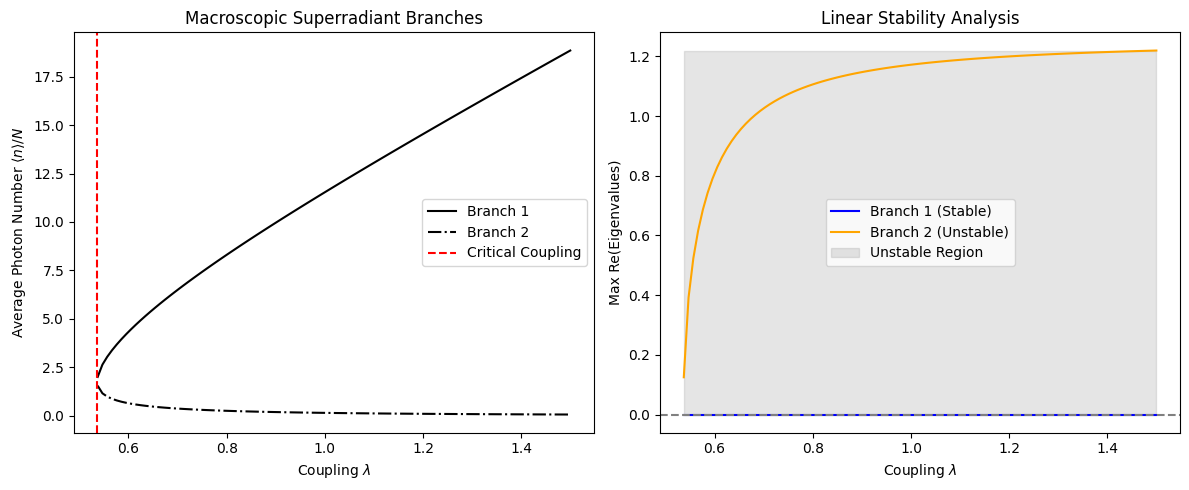

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
omega_c = 1.0
omega_a = 1.0
k2 = 0.05

# Calculate the TRUE critical coupling for Spin-1 normalization
lam_c = 0.5 * np.sqrt(omega_c**2 + 3 * omega_a * k2)
print(f"Critical Coupling (lambda_c): {lam_c:.4f}")

# --- 2. Equations of Motion ---
def eoms(vars_array, lam, omega_c, omega_a, k2):
    """
    Returns the time derivatives based on the cumulant expansion.
    Corrected to remove the paper's flawed 2*omega_a factor.
    """
    a, a_dag, a2, a2_dag, n, Jx, Jy, Jz = vars_array

    da      = -1j*omega_c*a - 2j*lam*Jx*a_dag - k2*(2*n*a + a2*a_dag - 2*(a**2)*a_dag)
    da_dag  =  1j*omega_c*a_dag + 2j*lam*Jx*a - k2*(2*n*a_dag + a2_dag*a - 2*(a_dag**2)*a)
    
    da2     = -2j*omega_c*a2 - 4j*lam*Jx*n - 2*k2*(3*n*a2 - 2*a_dag*(a**3))
    da2_dag =  2j*omega_c*a2_dag + 4j*lam*Jx*n - 2*k2*(3*n*a2_dag - 2*a*(a_dag**3))
    
    dn      =  2j*lam*Jx*(a2 - a2_dag) - k2*(4*(n**2) - 4*(a_dag**2)*(a**2) + 2*a2_dag*a2)
    
    # Corrected Heisenberg commutators
    dJx     = -omega_a*Jy
    dJy     =  omega_a*Jx - 2*lam*Jz*(a2 + a2_dag)
    dJz     =  2*lam*Jy*(a2 + a2_dag)

    return np.array([da, da_dag, da2, da2_dag, dn, dJx, dJy, dJz], dtype=complex)

# --- 3. Stability Checker ---
def get_max_real_eigenvalue(ss_vars, lam, omega_c, omega_a, k2, epsilon=1e-8):
    """
    Computes the Bogoliubov (Jacobian) matrix numerically and returns the 
    maximum real part of its eigenvalues.
    """
    n_vars = len(ss_vars)
    jacobian = np.zeros((n_vars, n_vars), dtype=complex)
    base_eoms = eoms(ss_vars, lam, omega_c, omega_a, k2)

    # Finite difference for Jacobian construction
    for i in range(n_vars):
        perturbed_vars = np.copy(ss_vars)
        perturbed_vars[i] += epsilon
        perturbed_eoms = eoms(perturbed_vars, lam, omega_c, omega_a, k2)
        jacobian[:, i] = (perturbed_eoms - base_eoms) / epsilon

    eigenvalues = np.linalg.eigvals(jacobian)
    return np.max(np.real(eigenvalues))

# --- 4. Analytical Steady States ---
lam_vals = np.linspace(lam_c + 0.001, 1.5, 100) # Start just above critical point
max_re_branch1 = []
max_re_branch2 = []
n_branch1 = []
n_branch2 = []

for lam in lam_vals:
    # Corrected polynomial coefficients for Spin-1 constraint
    A = 144 * omega_c**2 * lam**2 * k2**2 + 81 * omega_a**2 * k2**4
    B = 16 * omega_c**4 * lam**2 + 18 * omega_a**2 * k2**2 * omega_c**2 - 64 * omega_c**2 * lam**4
    C = omega_a**2 * omega_c**4
    
    # Discriminant
    disc = B**2 - 4*A*C
    if disc < 0:
        disc = 0 
        
    # Two roots for x = n^2
    x1 = (-B + np.sqrt(disc)) / (2*A)
    x2 = (-B - np.sqrt(disc)) / (2*A)
    
    # Branch 1 (Upper, Stable)
    n1 = np.sqrt(x1)
    Jx1 = np.sqrt((9 * k2**2 * n1**2 + omega_c**2) / (4 * lam**2))
    Jz1 = -(omega_a * (9 * k2**2 * n1**2 + omega_c**2)) / (8 * lam**2 * omega_c * n1)
    a2_1 = (-2j * lam * Jx1 * n1) / (3 * k2 * n1 + 1j * omega_c)
    
    ss1 = np.array([0, 0, a2_1, np.conj(a2_1), n1, Jx1, 0, Jz1], dtype=complex)
    max_re_branch1.append(get_max_real_eigenvalue(ss1, lam, omega_c, omega_a, k2))
    n_branch1.append(n1)
    
    # Branch 2 (Lower, Unstable)
    n2 = np.sqrt(x2)
    Jx2 = np.sqrt((9 * k2**2 * n2**2 + omega_c**2) / (4 * lam**2))
    Jz2 = -(omega_a * (9 * k2**2 * n2**2 + omega_c**2)) / (8 * lam**2 * omega_c * n2)
    a2_2 = (-2j * lam * Jx2 * n2) / (3 * k2 * n2 + 1j * omega_c)
    
    ss2 = np.array([0, 0, a2_2, np.conj(a2_2), n2, Jx2, 0, Jz2], dtype=complex)
    max_re_branch2.append(get_max_real_eigenvalue(ss2, lam, omega_c, omega_a, k2))
    n_branch2.append(n2)

# --- 5. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Photon Number (Macroscopic Branches)
ax1.plot(lam_vals, n_branch1, label='Branch 1', color='black', linestyle='-')
ax1.plot(lam_vals, n_branch2, label='Branch 2', color='black', linestyle='-.')
ax1.axvline(lam_c, color='red', linestyle='--', label='Critical Coupling')
ax1.set_xlabel('Coupling $\\lambda$')
ax1.set_ylabel('Average Photon Number $\\langle n \\rangle / N$')
ax1.set_title('Macroscopic Superradiant Branches')
ax1.legend()

# Plot 2: Stability (Max Real Part of Eigenvalues)
ax2.plot(lam_vals, max_re_branch1, label='Branch 1 (Stable)', color='blue')
ax2.plot(lam_vals, max_re_branch2, label='Branch 2 (Unstable)', color='orange')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel('Coupling $\\lambda$')
ax2.set_ylabel('Max Re(Eigenvalues)')
ax2.set_title('Linear Stability Analysis')
ax2.fill_between(lam_vals, 0, max(max_re_branch2), color='gray', alpha=0.2, label='Unstable Region')
ax2.legend()

plt.tight_layout()
plt.show()

Critical Coupling (lambda_c): 0.5123


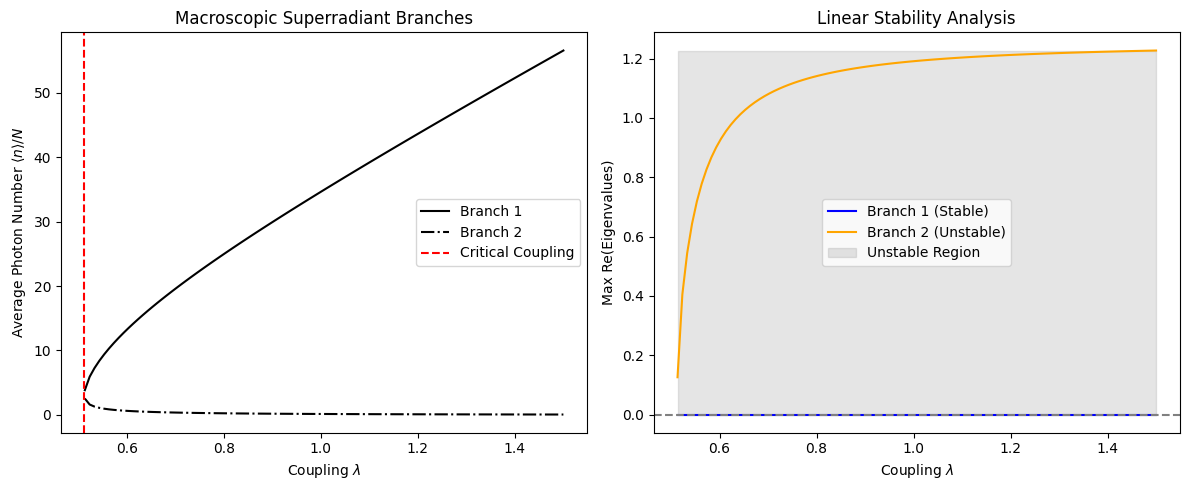

In [12]:
# --- 1. System Parameters ---
omega_c = 1.0
omega_a = 1.0
k2 = 0.05

# Calculate the TRUE critical coupling derived from the pure branch
lam_c = 0.5 * np.sqrt(omega_c**2 + omega_a * k2)
print(f"Critical Coupling (lambda_c): {lam_c:.4f}")

# --- 2. Equations of Motion ---
def eoms(vars_array, lam, omega_c, omega_a, k2):
    """
    Returns the time derivatives based on the exact single-branch derivation.
    The spurious cumulant expansion factors (like 3 and 9) have been removed.
    """
    a, a_dag, a2, a2_dag, n, Jx, Jy, Jz = vars_array

    # Single-photon operators (decay normally, uncoupled from cumulant artifacts)
    da      = -1j*omega_c*a - 2j*lam*Jx*a_dag - k2*n*a
    da_dag  =  1j*omega_c*a_dag + 2j*lam*Jx*a - k2*n*a_dag
    
    # Exact branch two-photon and number operators
    da2     = -2j*omega_c*a2 - 4j*lam*Jx*n - 2*k2*n*a2
    da2_dag =  2j*omega_c*a2_dag + 4j*lam*Jx*n - 2*k2*n*a2_dag
    
    dn      =  2j*lam*Jx*(a2 - a2_dag) - 2*k2*(n**2)
    
    # Collective spin operators
    dJx     = -omega_a*Jy
    dJy     =  omega_a*Jx - 2*lam*Jz*(a2 + a2_dag)
    dJz     =  2*lam*Jy*(a2 + a2_dag)

    return np.array([da, da_dag, da2, da2_dag, dn, dJx, dJy, dJz], dtype=complex)

# --- 3. Stability Checker ---
def get_max_real_eigenvalue(ss_vars, lam, omega_c, omega_a, k2, epsilon=1e-8):
    """
    Computes the Bogoliubov (Jacobian) matrix numerically and returns the 
    maximum real part of its eigenvalues.
    """
    n_vars = len(ss_vars)
    jacobian = np.zeros((n_vars, n_vars), dtype=complex)
    base_eoms = eoms(ss_vars, lam, omega_c, omega_a, k2)

    # Finite difference for Jacobian construction
    for i in range(n_vars):
        perturbed_vars = np.copy(ss_vars)
        perturbed_vars[i] += epsilon
        perturbed_eoms = eoms(perturbed_vars, lam, omega_c, omega_a, k2)
        jacobian[:, i] = (perturbed_eoms - base_eoms) / epsilon

    eigenvalues = np.linalg.eigvals(jacobian)
    return np.max(np.real(eigenvalues))

# --- 4. Analytical Steady States ---
lam_vals = np.linspace(lam_c + 0.001, 1.5, 100) # Start just above critical point
max_re_branch1 = []
max_re_branch2 = []
n_branch1 = []
n_branch2 = []

for lam in lam_vals:
    # Corrected polynomial coefficients for the pure symmetry branch
    A = 16 * (lam**2) * (omega_c**2) * (k2**2) + (omega_a**2) * (k2**4)
    B = 16 * (lam**2) * (omega_c**4) + 2 * (omega_a**2) * (omega_c**2) * (k2**2) - 64 * (lam**4) * (omega_c**2)
    C = (omega_a**2) * (omega_c**4)
    
    # Discriminant
    disc = B**2 - 4*A*C
    if disc < 0:
        disc = 0 
        
    # Two roots for x = n^2
    x1 = (-B + np.sqrt(disc)) / (2*A)
    x2 = (-B - np.sqrt(disc)) / (2*A)
    
    # Branch 1 (Upper, Stable)
    n1 = np.sqrt(x1)
    Jx1 = np.sqrt((k2**2 * n1**2 + omega_c**2) / (4 * lam**2))
    Jz1 = -(omega_a * (k2**2 * n1**2 + omega_c**2)) / (8 * lam**2 * omega_c * n1)
    a2_1 = (-2j * lam * Jx1 * n1) / (k2 * n1 + 1j * omega_c)
    
    ss1 = np.array([0, 0, a2_1, np.conj(a2_1), n1, Jx1, 0, Jz1], dtype=complex)
    max_re_branch1.append(get_max_real_eigenvalue(ss1, lam, omega_c, omega_a, k2))
    n_branch1.append(n1)
    
    # Branch 2 (Lower, Unstable)
    n2 = np.sqrt(x2)
    Jx2 = np.sqrt((k2**2 * n2**2 + omega_c**2) / (4 * lam**2))
    Jz2 = -(omega_a * (k2**2 * n2**2 + omega_c**2)) / (8 * lam**2 * omega_c * n2)
    a2_2 = (-2j * lam * Jx2 * n2) / (k2 * n2 + 1j * omega_c)
    
    ss2 = np.array([0, 0, a2_2, np.conj(a2_2), n2, Jx2, 0, Jz2], dtype=complex)
    max_re_branch2.append(get_max_real_eigenvalue(ss2, lam, omega_c, omega_a, k2))
    n_branch2.append(n2)

# --- 5. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Photon Number (Macroscopic Branches)
ax1.plot(lam_vals, n_branch1, label='Branch 1', color='black', linestyle='-')
ax1.plot(lam_vals, n_branch2, label='Branch 2', color='black', linestyle='-.')
ax1.axvline(lam_c, color='red', linestyle='--', label='Critical Coupling')
ax1.set_xlabel('Coupling $\\lambda$')
ax1.set_ylabel('Average Photon Number $\\langle n \\rangle / N$')
ax1.set_title('Macroscopic Superradiant Branches')
ax1.legend()

# Plot 2: Stability (Max Real Part of Eigenvalues)
ax2.plot(lam_vals, max_re_branch1, label='Branch 1 (Stable)', color='blue')
ax2.plot(lam_vals, max_re_branch2, label='Branch 2 (Unstable)', color='orange')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel('Coupling $\\lambda$')
ax2.set_ylabel('Max Re(Eigenvalues)')
ax2.set_title('Linear Stability Analysis')
ax2.fill_between(lam_vals, 0, max(max_re_branch2), color='gray', alpha=0.2, label='Unstable Region')
ax2.legend()

plt.tight_layout()
plt.show()

4.236441166076507


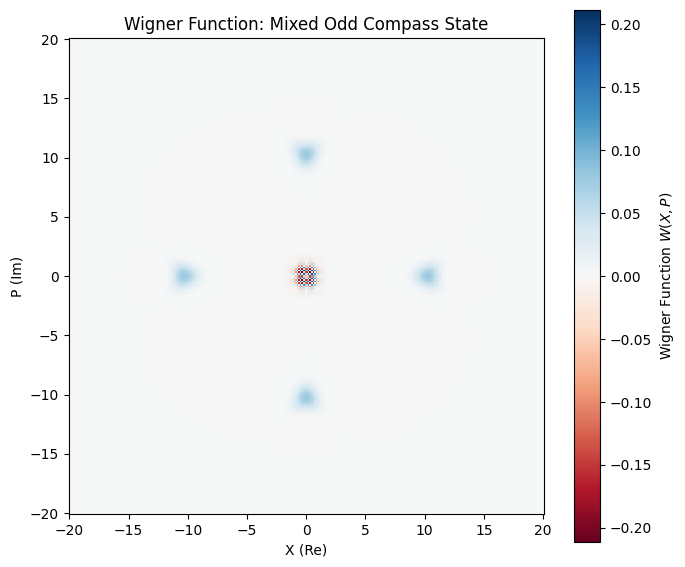

In [ ]:
import qutip as qt

# --- 1. Parameters ---
N_fock = 120 # Truncation of the Fock space (make sure it's large enough for alpha)
ntest = 80
alpha_val = (((k2**2)*ntest**4 + (omega_c**2)*ntest**2 )/ (9*k2*ntest**2 + omega_c**2))**(1/4)      # Coherent state amplitude (distance from origin)
print(alpha_val)
alpha_val = 9

# --- 2. Construct the Pure Odd Cat States ---
# Horizontal odd cat: |alpha> - |-alpha>
state_H_plus  = qt.coherent(N_fock, alpha_val)
state_H_minus = qt.coherent(N_fock, -alpha_val)
cat_H_odd = (state_H_plus - state_H_minus).unit()

# Vertical odd cat: |i*alpha> - |-i*alpha>
state_V_plus  = qt.coherent(N_fock, 1j * alpha_val)
state_V_minus = qt.coherent(N_fock, -1j * alpha_val)
cat_V_odd = (state_V_plus - state_V_minus).unit()

# --- 3. Create the Statistical Mixture ---
# Convert pure states to density matrices
rho_H = cat_H_odd * cat_H_odd.dag()
rho_V = cat_V_odd * cat_V_odd.dag()

# 50/50 Statistical Mixture
rho_mixed = 0.5 * rho_H + 0.5 * rho_V

# --- 4. Calculate and Plot the Wigner Function ---
xvec = np.linspace(-20, 20, 300)
W = qt.wigner(rho_mixed, xvec, xvec)

# Find max absolute value to center the colormap symmetrically at zero
w_max = np.max(np.abs(W))

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(xvec, xvec, W, cmap='RdBu', shading='auto', 
                      vmin=-w_max, vmax=w_max)

plt.xlabel('X (Re)')
plt.ylabel('P (Im)')
plt.title('Wigner Function: Mixed Odd Compass State')
plt.colorbar(mesh, label='Wigner Function $W(X,P)$')
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

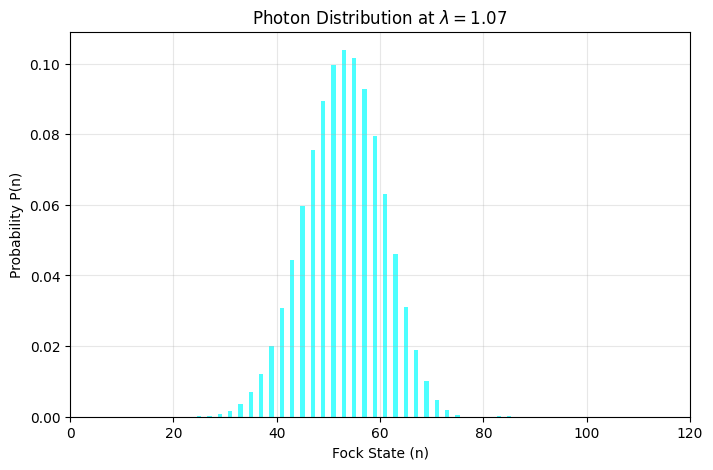

In [17]:
P_m_n = rho_mixed.diag()

plt.figure(figsize=(8, 5))
plt.bar(range(N_fock), P_m_n[:N_fock], color='cyan', alpha=0.7)
plt.xlabel('Fock State (n)')
plt.ylabel('Probability P(n)')
plt.title(f'Photon Distribution at $\lambda=1.07$')
plt.xlim(0, N_fock)
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
rho_ss_loaded_E = qt.qload(r'C:\Users\genes\Documents\Studium\FS26\Master Thesis\Code\Plots\Two_photon_dicke_2p_jump\Plot_Data\TPDT_N15_M120_l053_t70_n700_E')
rho_ss_loaded_O = qt.qload(r'C:\Users\genes\Documents\Studium\FS26\Master Thesis\Code\Plots\Two_photon_dicke_2p_jump\Plot_Data\TPDT_N15_M120_l053_t70_n700_O')

C:\Users\genes\AppData\Local\Temp\ipykernel_15860\109615203.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\genes\AppData\Local\Temp\ipykernel_15860\109615203.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


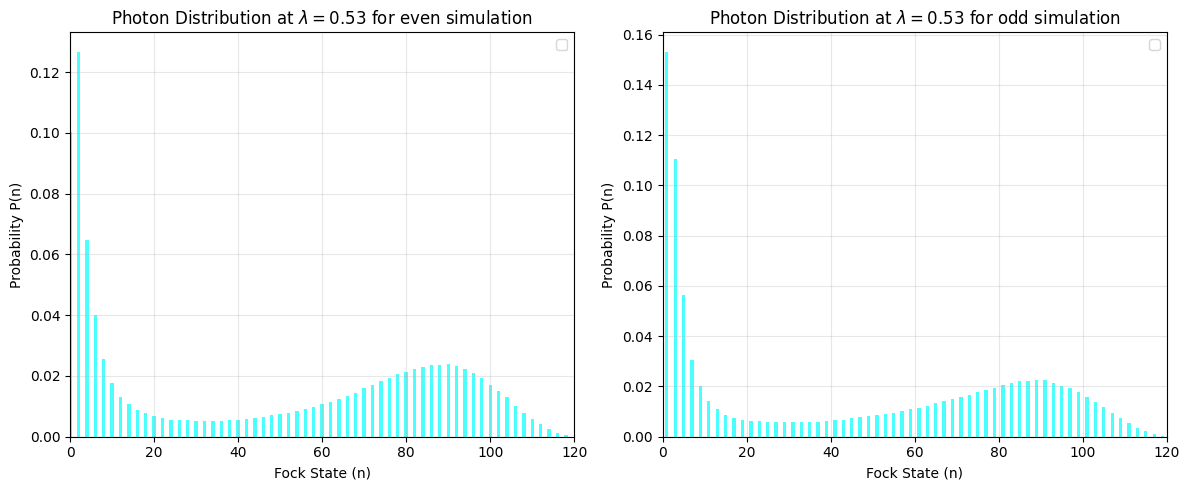

In [23]:
M_fock = 120
rho_cavity_loaded_even = rho_ss_loaded_E.ptrace(0)
rho_cavity_loaded_odd = rho_ss_loaded_O.ptrace(0)

P_n_E = rho_cavity_loaded_even.diag()
P_n_O = rho_cavity_loaded_odd.diag()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Photon Number (Macroscopic Branches)
ax1.bar(range(M_fock), P_n_E[:M_fock], color='cyan', alpha=0.7)
ax1.set_xlabel('Fock State (n)')
ax1.set_ylabel('Probability P(n)')
ax1.set_title(f'Photon Distribution at $\lambda=0.53$ for even simulation')
ax1.set_xlim(0,M_fock)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Stability (Max Real Part of Eigenvalues)
ax2.bar(range(M_fock), P_n_O[:M_fock], color='cyan', alpha=0.7)
ax2.set_xlabel('Fock State (n)')
ax2.set_ylabel('Probability P(n)')
ax2.set_title(f'Photon Distribution at $\lambda=0.53$ for odd simulation')
ax2.set_xlim(0,M_fock)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

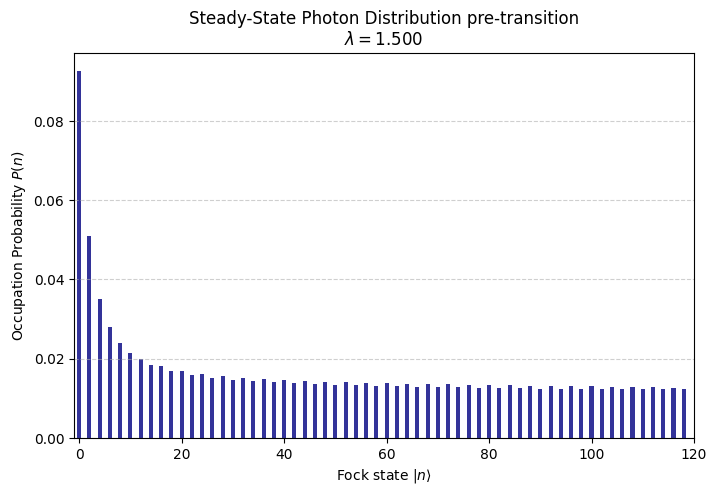

Significant Fock state populations (Even sector):
|0> : 0.092570
|2> : 0.050802
|4> : 0.035123
|6> : 0.027921
|8> : 0.023990
|10> : 0.021263
|12> : 0.019980
|14> : 0.018423
|16> : 0.018017
|18> : 0.016854
|20> : 0.016851
|22> : 0.015860
|24> : 0.016077
|26> : 0.015175
|28> : 0.015524
|30> : 0.014674
|32> : 0.015110
|34> : 0.014291
|36> : 0.014787
|38> : 0.013989
|40> : 0.014528
|42> : 0.013743
|44> : 0.014316
|46> : 0.013539
|48> : 0.014139
|50> : 0.013366
|52> : 0.013989
|54> : 0.013216
|56> : 0.013859
|58> : 0.013086
|60> : 0.013746
|62> : 0.012970
|64> : 0.013645
|66> : 0.012866
|68> : 0.013554
|70> : 0.012772
|72> : 0.013470
|74> : 0.012686
|76> : 0.013392
|78> : 0.012608
|80> : 0.013318
|82> : 0.012537
|84> : 0.013247
|86> : 0.012472
|88> : 0.013178
|90> : 0.012414
|92> : 0.013109
|94> : 0.012362
|96> : 0.013039
|98> : 0.012316
|100> : 0.012969
|102> : 0.012277
|104> : 0.012896
|106> : 0.012246
|108> : 0.012817
|110> : 0.012225
|112> : 0.012724
|114> : 0.012223
|116> : 0.012578
|1

In [78]:
def calculate_fock_distribution(N, omega_c, omega_a, kappa_2, lambda_c, N_fock):
    """
    Calculates the steady-state Fock distribution for the effective 
    two-photon Dicke model pre-transition.
    
    Parameters:
    N           : int, Number of spins (scaling factor)
    omega_c     : float, Cavity frequency
    omega_a     : float, Emitter frequency
    kappa_2     : float, Two-photon loss rate
    lambda_c    : float, coupling rate, should stay below 0.53
    N_fock      : int, Truncation dimension for the Fock space
    """
    # 1. System Parameters
    lambda_coup = lambda_c
    
    # 2. Operators
    a = qt.destroy(N_fock)
    a_dag = a.dag()
    n_op = a_dag * a
    X = a_dag**2 + a**2
    
    # 3. Construct the Effective Hamiltonian
    # Energy denominator: (omega_a^2 - 4 * omega_c^2)
    denom = omega_a**2 - 4 * omega_c**2
    
    # Bare cavity energy
    H_bare = omega_c * n_op -2*omega_a*N
    
    # Non-linear interaction term
    H_nl = - (lambda_coup**2 * omega_a) / (N * denom) * (X * X)
    
    # Finite-size Stark shift correction
    H_stark = (2 * lambda_coup**2 * omega_c) / (N * denom) * (4* n_op + 2)
    
    H_eff = H_bare + H_nl + H_stark
    
    # 4. Jump Operator for two-photon loss
    # L2 = sqrt(kappa_2 / N) * a^2
    L2 = np.sqrt(kappa_2 / N) * a**2
    
    # 5. Solve for Steady State
    # Note: For two-photon loss only, parity is conserved. 
    # If the system starts in vacuum (even), it stays in the even sector.
    rho_ss = qt.steadystate(H_eff, [L2])
    
    # 6. Extract Occupation Probabilities (Diagonals)
    probabilities = rho_ss.diag()
    
    return rho_ss, probabilities



N_spins = 15
w_c = 1.0
w_a = 1.0
k_2 = 0.05
    
    # Evaluate at 90% of the critical coupling
Lambda = 2.3
fock_cutoff = 120  
    
rho_test, probs = calculate_fock_distribution(
    N=N_spins, 
    omega_c=w_c, 
    omega_a=w_a, 
    kappa_2=k_2, 
    lambda_c=Lambda, 
    N_fock=fock_cutoff
)
    
# Plotting the results
plt.figure(figsize=(8, 5))
plt.bar(range(fock_cutoff), probs, color='navy', alpha=0.8)
plt.title(f"Steady-State Photon Distribution pre-transition\n$\lambda = {lam:.3f}$")
plt.xlabel("Fock state $|n\\rangle$")
plt.ylabel("Occupation Probability $P(n)$")
plt.xlim(-1, fock_cutoff)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
    
# Print non-zero even coefficients

print("Significant Fock state populations (Even sector):")
for n, p in enumerate(probs):
    if p > 1e-5:
        print(f"|{n}> : {p:.6f}")
